<a href="https://colab.research.google.com/github/rpark3/ECON3916-Statistical-Machine-Learning/blob/main/Project%201/Econ3916_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
url = "https://raw.githubusercontent.com/rpark3/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/lalonde.csv"
df = pd.read_csv(url)
df


,Unnamed: 0,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,1,1,37,11,1,0,1,1,0.0,0.0,9930.0460
1,2,1,22,9,0,1,0,1,0.0,0.0,3595.8940
2,3,1,30,12,1,0,0,0,0.0,0.0,24909.4500
3,4,1,27,11,1,0,0,1,0.0,0.0,7506.1460
4,5,1,33,8,1,0,0,1,0.0,0.0,289.7899
...,...,...,...,...,...,...,...,...,...,...,...
609,610,0,18,11,0,0,0,1,0.0,0.0,10150.5000
610,611,0,24,1,0,1,1,1,0.0,0.0,19464.6100
611,612,0,21,18,0,0,0,0,0.0,0.0,0.0000
612,613,0,32,5,1,0,1,1,0.0,0.0,187.6713


In [ ]:
#print(df.info())
#print(df.describe())

variables = ['re78', 'educ', 're74', 're75', 'black', 'hispan', 'nodegree']

table1 = pd.DataFrame({
    'Control Mean': df[df['treat'] == 0][variables].mean(),
    'Treatment Mean': df[df['treat'] == 1][variables].mean(),
    'Control SD': df[df['treat'] == 0][variables].std(),
    'Treatment SD': df[df['treat'] == 1][variables].std()
}).round(2)

print(table1)

print("Control N:", (df['treat'] == 0).sum())
print("Treatment N:", (df['treat'] == 1).sum())

          Control Mean  Treatment Mean  Control SD  Treatment SD
re78           6984.17         6349.14     7294.16       7867.40
educ             10.24           10.35        2.86          2.01
re74           5619.24         2095.57     6788.75       4886.62
re75           2466.48         1532.06     3292.00       3219.25
black             0.20            0.84        0.40          0.36
hispan            0.14            0.06        0.35          0.24
nodegree          0.60            0.71        0.49          0.46
Control N: 429
Treatment N: 185


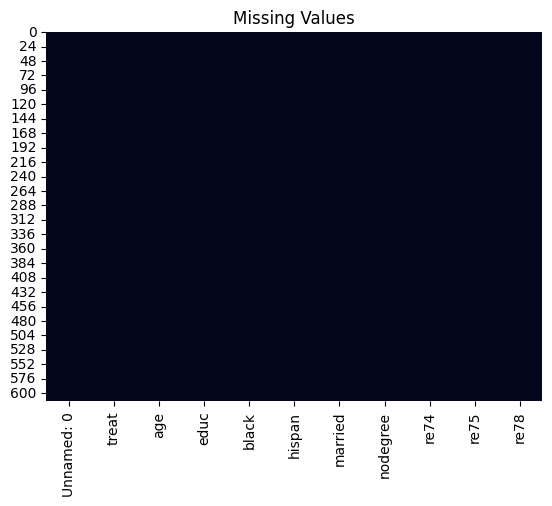

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values')
plt.show()

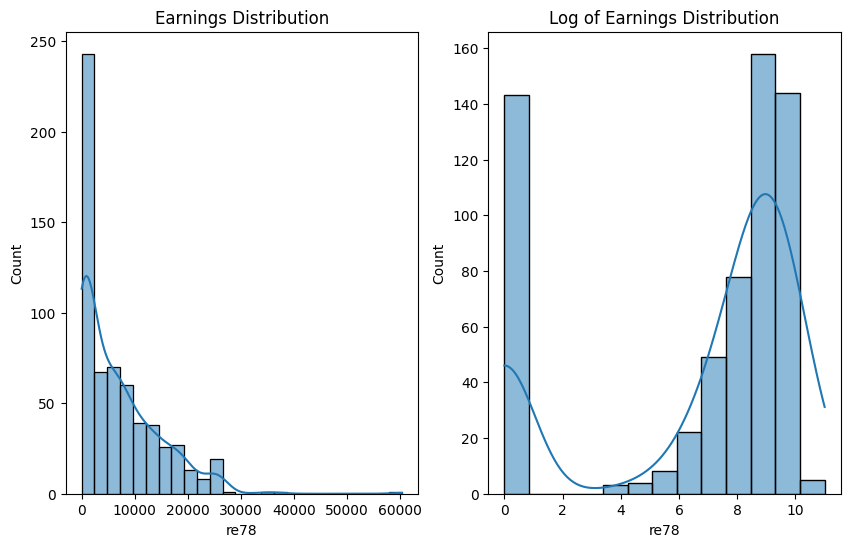

In [ ]:
# Visualizing the log-transformation
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['re78'], kde=True)
plt.title("Earnings Distribution")

plt.subplot(1, 2, 2)
sns.histplot(np.log(df['re78']+1), kde=True)
plt.title("Log of Earnings Distribution")
plt.show()

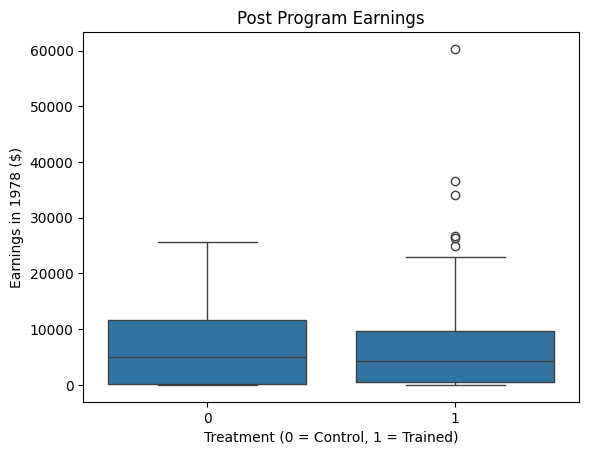

In [ ]:
sns.boxplot(x='treat', y='re78', data=df)
plt.title("Post Program Earnings")
plt.xlabel("Treatment (0 = Control, 1 = Trained)")
plt.ylabel("Earnings in 1978 ($)")
plt.show()

In [ ]:
# Manual Tukey Fence implementation
Q1 = df['re78'].quantile(0.25)
Q3 = df['re78'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['re78'] < (Q1 - 1.5 * IQR)) | (df['re78'] > (Q3 + 1.5 * IQR))]

print(f"Number of outliers detected: {len(outliers)}")
print(f"Outliers: {(outliers['re78'])}")

Number of outliers detected: 3
Outliers: 106    34099.28
131    60307.93
181    36646.95
Name: re78, dtype: float64


In [ ]:
# Manual Implementation of OLS with Heteroskedasticity-Robust Errors
import statsmodels.formula.api as smf

# Define the formula string: Y ~ D + X1 + X2
formula_1 = 'np.log(re78+1) ~ treat + educ + black + hispan + nodegree + re74 + re75 + married + age'

# Fit the model
model_1 = smf.ols(formula=formula_1, data=df).fit(cov_type='HC1')

# Print the "Regression Anatomy"
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:       np.log(re78 + 1)   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     7.588
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.40e-10
Time:                        15:12:01   Log-Likelihood:                -1662.4
No. Observations:                 614   AIC:                             3345.
Df Residuals:                     604   BIC:                             3389.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.2163      1.362      4.565      0.0

participation in the training program is associated with about 84.7% higher 1978 earnings, holding education, race/ethnicity, degree status, and prior earnings constant.

One additional year of education is associated with about 18.8% higher 1978 earnings, holding the other variables constant.

A $1,000 increase in 1975 earnings is associated with about 10% higher 1978 earnings, holding the other variables constant.

In [ ]:
formula_interact = 'np.log(re78+1) ~ treat * re75 + nodegree + black + hispan + re74 + educ + married + age'

model_interact = smf.ols(formula=formula_interact, data=df).fit(cov_type='HC1')
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:       np.log(re78 + 1)   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     6.860
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.40e-10
Time:                        15:10:59   Log-Likelihood:                -1662.0
No. Observations:                 614   AIC:                             3346.
Df Residuals:                     603   BIC:                             3395.
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1192      1.364      4.485      0.0

Interaction not statistically significant,
coef is negative which suggests treatement gets smaller as earnings in 1975 rise

In [ ]:
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_white

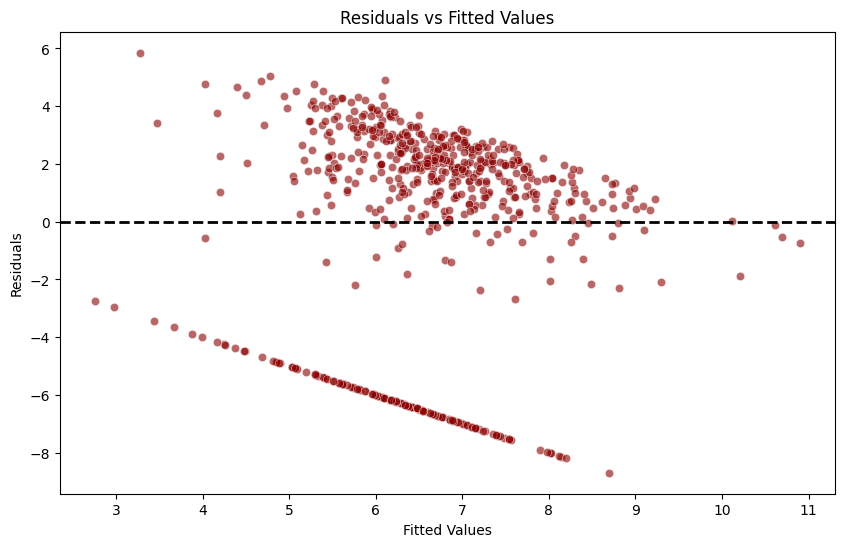

In [ ]:
fitted_vals = model_1.fittedvalues
residuals = model_1.resid

plt.figure(figsize=(10,6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, linestyle='--', linewidth=2, color='black')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

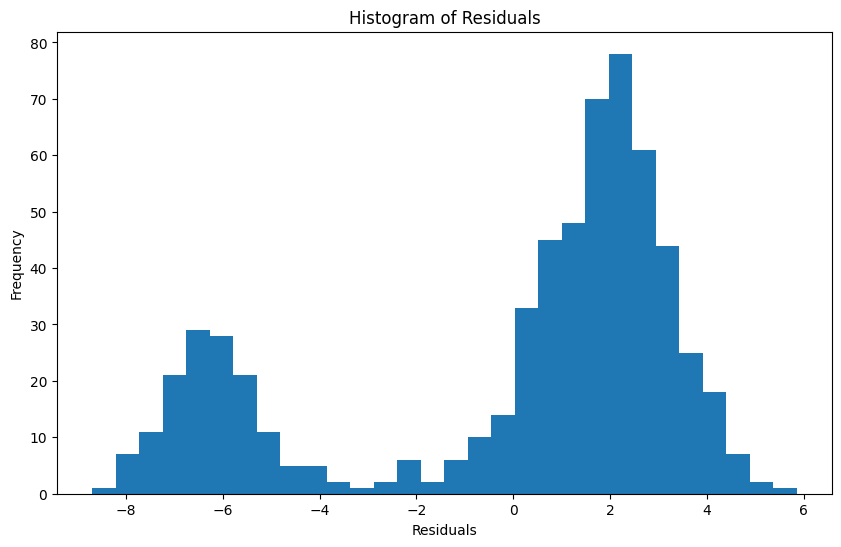

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(residuals, bins=30)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

<Figure size 1000x600 with 0 Axes>

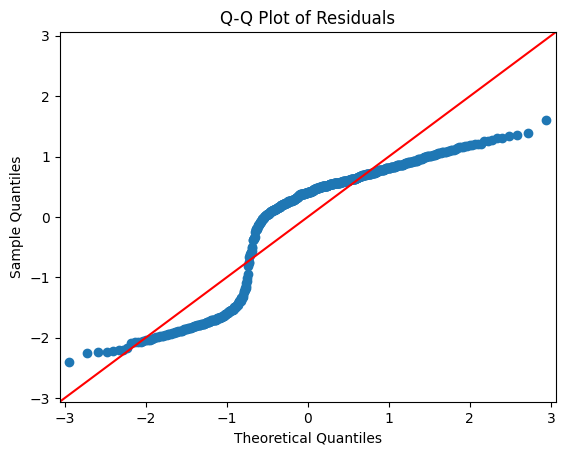

In [ ]:
plt.figure(figsize=(10,6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

In [ ]:
white_test = het_white(model_1.resid, model_1.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

print("White Test for Heteroskedasticity:")
for label, value in zip(labels, white_test):
    print(f"{label}: {value}")

White Test for Heteroskedasticity:
LM Statistic: 68.64496392212652
LM-Test p-value: 0.026829251731230574
F-Statistic: 1.4816190849013309
F-Test p-value: 0.02213821529502526


In [ ]:
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[df['re78'] <= upper_bound].copy()

import statsmodels.formula.api as smf

model_no_outliers = smf.ols(formula='np.log(re78 + 1) ~ treat + educ + black + hispan + nodegree + re74 + re75 + married + age',data=df_no_outliers).fit(cov_type='HC1')

print(model_no_outliers.summary())

                            OLS Regression Results                            
Dep. Variable:       np.log(re78 + 1)   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     7.369
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.12e-10
Time:                        20:54:19   Log-Likelihood:                -1654.2
No. Observations:                 611   AIC:                             3328.
Df Residuals:                     601   BIC:                             3372.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.2853      1.362      4.613      0.0